# Part 2: A continuous-time model
In this part transitions from one state to another can happen at any time (not just once a month, like in part 1)

### Importing necessary packages

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg

## Task 7
We will simulate the lifetime of 1000 women, all starting in state 1. We extract the mean and std dev. and their confidence intervals. Furthermore we find the proportion of women where the cancer has reappeared distantly (state 3 or 4) after 30.5 months.

In [2]:
# Defining the transition-rate matrix Q
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,      0.001 ], # State 1
    [ 0,     -0.014,  0.005,  0.004,  0.005 ], # State 2
    [ 0,      0,     -0.008,  0.003,  0.005 ], # State 3
    [ 0,      0,      0,     -0.009,  0.009 ], # State 4
    [ 0,      0,      0,      0,      0     ]  # State 5
])

states = [0, 1, 2, 3, 4]    # 0 indexed (corresponding to states 1,2,3,4,5)

Continuous time simulation results:
Mean lifetime: 262.42 months
95% CI for the mean: [250.70, 274.13]

Standard deviation: 188.75 months
95% CI for the standard deviation: [180.83, 197.41]

Proportion with distant recurrence after 30.5 months: 0.5970


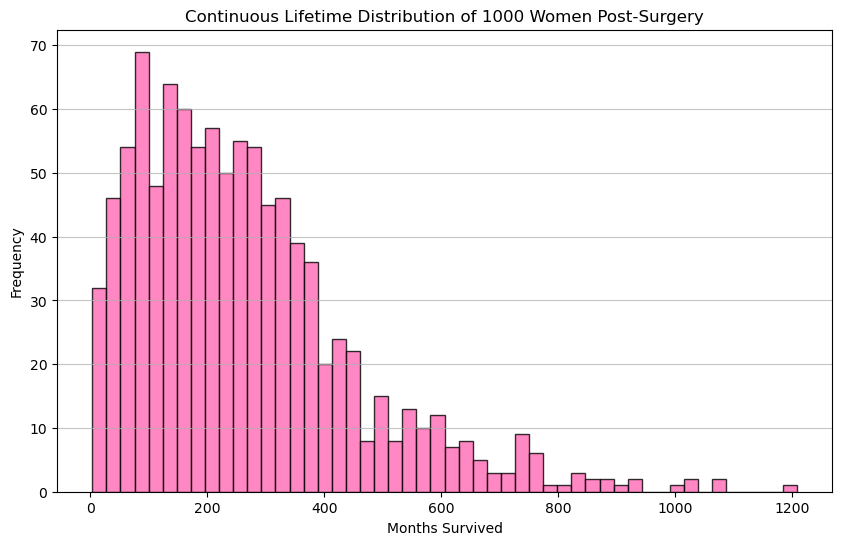

In [6]:
# Set seed for reproducibility
np.random.seed(2443)

num_women = 1000    # We want to simulate 1000 women

lifetimes = []  # List to store the lifetimes of the simulated women in
distant_after_30_5 = 0  # Counter for, for how many women the cancer reappeared distantly within 30.5 months


for _ in range(num_women):  # Running the loop for 1000 women
    current_state = 0   # Starting in state 1
    current_time = 0.0  # The initial lifetime after surgery
    
    got_distant = False # Boolean value for if the cancer reappeared distantly (staring as False)
    time_of_distant = 0.0   # What time the cancer reappeared distantly
    
    while current_state != 4: # Running until the woman dies
        
        # The rate of leaving the current state 
        lambda_i = -Q[current_state, current_state] # the negative of the diagonal
        
        # How long do they stay in this state
        sojourn_time = np.random.exponential(scale=1/lambda_i)  # # Drawn from an exponential distribution
        current_time += sojourn_time    # Updating the time
        
        # Which state do the enter next
        jump_rates = Q[current_state].copy()    # Extracting the rates for the current state
        jump_rates[current_state] = 0   # setting the diagonal to 0
        
        # Converting the rates to probabilities (now they will sum to 1)
        jump_probs = jump_rates / lambda_i
        
        # Picking the next state based on the probabilities
        next_state = np.random.choice(states, p=jump_probs)
        
        # Checking if the cancer reappeared distantly ( if the woman enters state 3 or 4)
        if next_state in [2, 3] and not got_distant:
            got_distant = True  # Updating the boolean
            time_of_distant = current_time  # Updating the time the cancer reappeared distantly
            
        # Updating the state
        current_state = next_state
        
    # Recording the lifetime when the woman has died (when the loop has finished)
    lifetimes.append(current_time)
    
    # Checking is the woman experience a distant recurrence after 30.5 months
    if got_distant and time_of_distant > 30.5:
        distant_after_30_5 += 1 # Updating the counter if the contitions where met


lifetimes = np.array(lifetimes) # Converting the list to an array
n = len(lifetimes)  # The total number of lifetimes simulated (should be 1000)

mean_lt = np.mean(lifetimes)    # Mean lifetime
std_lt = np.std(lifetimes, ddof=1)  # standard deviation of the lifetimes

# 95% Confidence interval for the mean (using t-distribution)
t_crit = stats.t.ppf(0.975, df=n-1)
margin_of_error_mean = t_crit * (std_lt / np.sqrt(n))
ci_mean = (mean_lt - margin_of_error_mean, mean_lt + margin_of_error_mean)

# 95% Confidence interval for the standard deviation (using chi-square distribution)
chi2_lower = stats.chi2.ppf(0.025, df=n-1)
chi2_upper = stats.chi2.ppf(0.975, df=n-1)
var_lt = std_lt ** 2
ci_var = ((n-1) * var_lt / chi2_upper, (n-1) * var_lt / chi2_lower)
ci_std = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))

proportion_distant = distant_after_30_5 / n

# Printing the results
print("Continuous time simulation results:")
print(f"Mean lifetime: {mean_lt:.2f} months")
print(f"95% CI for the mean: [{ci_mean[0]:.2f}, {ci_mean[1]:.2f}]")
print(f"\nStandard deviation: {std_lt:.2f} months")
print(f"95% CI for the standard deviation: [{ci_std[0]:.2f}, {ci_std[1]:.2f}]")
print(f"\nProportion with distant recurrence after 30.5 months: {proportion_distant:.4f}")

# Plotting a histogram of the lifetimes
plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=50, color='hotpink', edgecolor='black', alpha=0.8)
plt.title('Continuous Lifetime Distribution of 1000 Women Post-Surgery')
plt.xlabel('Months Survived')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Task 8
We compare the simulated empirical lifetime distribution function to the theoretical using a t-test.

In [ ]:
# Extracting the submatrix Q_s
Q_s = Q[0:4, 0:4]   # The first four rows and columns of Q

# Initial state distribution pi (Always starting in state 1)
pi_0 = np.array([1, 0, 0, 0])

# Defining a column vector of ones, to use in calculations for the theoretical expected lifetime
ones = np.ones(4)


# Defining the theoretical cdf function
def theoretical_cdf(t):
    matrix_exp = scipy.linalg.expm(Q_s * t)
    
    # Calculating the probability of still being alive, then subtract from 1 to get probability of death
    prob_alive = np.dot(pi_0, np.dot(matrix_exp, ones))
    return 1 - prob_alive   # F_T(t) = 1 - p_0 * exp(Q_s * t) * 1


# Vectorizing the theoretical function to be able to calculate the matrix exponential for every simulated lifetime.
vectorized_cdf = np.vectorize(theoretical_cdf)

# Running the kolmogorov Smirnov test for comparison of the simulated and the theoretical distribution
ks_stat, p_value = stats.kstest(lifetimes, vectorized_cdf)

# Printing the results
print("Statistical comparison (Kolmogorov Smirnov Test):")
print(f"Test statistic: {ks_stat:.4f}")
print(f"P-value:        {p_value:.4f}")


Statistical comparison (Kolmogorov Smirnov Test):
Test statistic: 0.0234
P-value:        0.6336

Conclusion: Fail to reject the null hypothesis.
Meaning:    The simulated empirical distribution perfectly matches the theoretical distribution function!


We observe that the p-value is 0.6336 so we can not reject the null hypothesis that the simulation matched the theoretical distribution.

## Task 9
Now we will simulate 100 women who have recieved preventitive treatment and look at if the treatment seem to have an effect.

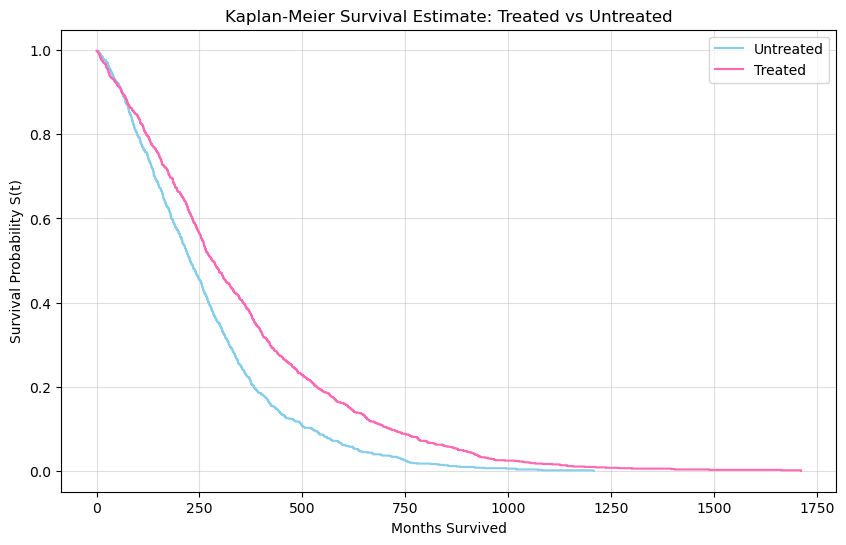

In [16]:
# The diagonal elements are found as the negative of the sum of the rows (example Q_treated[0,0] = -(0.0025 + 0.00125 + 0 + 0.001) = -0.00475)
# Defining the new Q matrix with the calculated diagonal elements
Q_treated = np.array([
    [-0.00475, 0.0025, 0.00125, 0,      0.001 ],
    [ 0,      -0.0070, 0,       0.002,  0.005 ],
    [ 0,       0,     -0.0080,  0.003,  0.005 ],
    [ 0,       0,      0,      -0.0090, 0.009 ],
    [ 0,       0,      0,       0,      0     ]
])

states = [0, 1, 2, 3, 4]    # Corresponding to states 1, 2, 3, 4, 5
num_women = 1000 # Number of women to simulate
lifetimes_treated = []  # List to store the lifetimes of the simulated women who have received the treatment

# Running the simulation
for _ in range(num_women):  # Running the loop for 1000 women
    current_state = 0   # Starting at state 1 (index 0)
    current_time = 0.0  # Initializing the survival time for this specific woman
    
    while current_state != 4:  # Running this loop until the woman dies (reaches state 5, index 4)
        
        # Extract the total rate of leaving the current state
        lambda_i = -Q_treated[current_state, current_state] # The negative diagonal
        
        # The sojourn time. How long the woman stays in the current state
        sojourn_time = np.random.exponential(scale=1/lambda_i)  # The time spent in a state follows an exponential distribution with a mean of 1/lambda_i
        current_time += sojourn_time  # Update the survival time
        
        # Finding which state the woman goes to next
        jump_rates = Q_treated[current_state].copy() # Get all transition rates for the current state
        jump_rates[current_state] = 0 # Set the diagonal to 0, because a woman cannot go to the same state again
        
        # Converting the transition rates into probabilities (sum to 1)
        jump_probs = jump_rates / lambda_i

        next_state = np.random.choice(states, p=jump_probs) # Choosing the next state based on the probabilities
        current_state = next_state # Update the state for the next iteration
        
    # Record the lifetime when the woman has died (when the inner loop finishes)
    lifetimes_treated.append(current_time)

lifetimes_treated = np.array(lifetimes_treated) # Converting the list to a numpy array


# Calculating the Kaplan Meier survival curves

# Survival porportion for the untreated women 
sorted_untreated = np.sort(lifetimes)
survival_untreated = 1 - np.arange(1, len(sorted_untreated) + 1) / len(sorted_untreated)

# Survival porportion for the treated women
sorted_treated = np.sort(lifetimes_treated)
survival_treated = 1 - np.arange(1, len(sorted_treated) + 1) / len(sorted_treated)


# Plotting 
plt.figure(figsize=(10, 6))

# plt.step creates the classic "staircase" look of a Kaplan-Meier plot
plt.step(sorted_untreated, survival_untreated, where='post', label='Untreated', color='skyblue')
plt.step(sorted_treated, survival_treated, where='post', label='Treated', color='hotpink')

plt.title('Kaplan-Meier Survival Estimate: Treated vs Untreated')
plt.xlabel('Months Survived')
plt.ylabel('Survival Probability S(t)')
plt.legend()
plt.grid(alpha=0.4)
plt.show()